<a href="https://colab.research.google.com/github/BrendJ510/Proyectos-Escolares/blob/main/ModelosNosupervisados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
iris .describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
species_count = iris["species"].value_counts().reset_index()
species_count.columns = ['species', 'count']
species_count

,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


In [ ]:
fig = px.histogram(species_count, x = "species", nbins = 30,title = "Distribution Of Flowers")
fig.update_layout(xaxis_title = "Species",yaxis_title = "Count",template = "plotly_white", bargap = 0.2)
fig.show()

In [ ]:
fig = go.Figure()
for feature in iris.columns[:-1]:
  fig.add_trace(go.Box(y = iris[feature],x = iris["species"], name = feature))
fig.update_layout(title = "Grafica de caja por especie", xaxis_title = "Especie", yaxis_title = "Valor")
fig.show()

In [ ]:
corr_matrix = iris.drop('species',axis=1).corr()
fig = px.imshow(corr_matrix,x = corr_matrix.columns, y = corr_matrix.columns, color_continuous_scale = "RdBu", range_color = [-1,1], text_auto = True, aspect = "auto")
fig.update_layout(title = "Correlation Heatmap")
fig.update(layout_coloraxis_showscale=False)
fig.show()

In [ ]:
fig= px.scatter_matrix(iris,dimensions=iris.columns[:-1], color ='species',template='plotly_white')
fig.update_traces(diagonal_visible=False)
fig.update_layout(title = "Pairplot of iris Dataset")
fig.show()


In [ ]:
X = iris.drop('species', axis=1)
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters = k, random_state=30, n_init =10)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

wcss

[681.3705999999996,
 152.34795176035797,
 78.851441426146,
 57.22847321428572,
 46.44618205128204,
 39.03998724608725,
 34.40900974025975,
 30.093465689916506,
 28.247948051948057,
 25.999374018747602]

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = list(range(1,11)), y = wcss, mode = 'lines+markers', name= 'WCSS',
                         ))
fig.update_layout(title = "Metodo del codo", xaxis_title = "Numero of Clusters (k)", yaxis_title = "WCSS",
                  xaxis=dict(tickmode = 'linear',tickvals=list(range(1,11))),yaxis=dict(rangemode ='tozero'),template = "plotly_white")
fig.show()

In [ ]:
silhouette_scores=[]

for k in range(2,11):
  kmeans = KMeans(n_clusters = k, random_state=42, n_init =10)
  cluster_labels = kmeans.fit_predict(X)
  silhouette_scores.append(silhouette_score(X, cluster_labels))
silhouette_scores

[np.float64(0.6810461692117465),
 np.float64(0.5528190123564102),
 np.float64(0.49805050499728815),
 np.float64(0.49123997967644867),
 np.float64(0.36483400396700366),
 np.float64(0.3542978877198859),
 np.float64(0.34873453772194),
 np.float64(0.3125044083968402),
 np.float64(0.31796622568242217)]

In [ ]:
fig= go.Figure()
fig.add_trace(go.Scatter(x = list(range(2,11)), y = silhouette_scores, mode = 'lines+markers', name= 'Silhouette Score',
                         ))
fig.update_layout(title = "Silhouette Score for optimal K", xaxis_title = "Numero of Clusters (k)", yaxis_title = "Silhouette Score",
                  xaxis=dict(tickmode = 'linear',tickvals=list(range(2,11))),yaxis = dict(rangemode ='tozero'),template = "plotly_white")
fig.show()

#Kmeans

In [ ]:
kmeans = KMeans(n_clusters = 2, random_state=42, n_init = 10)
kmeans.fit(X)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
iris_c2 = iris.copy()

In [ ]:
iris_c2['Cluster']= kmeans.labels_
iris_c2['Cluster'] = iris_c2.Cluster.astype(str) #a cadena pq lo pasa en entero
fig = px.scatter(iris_c2, x = 'sepal_length', y = 'petal_length', color = 'Cluster', title='Kmeans-2')
fig.show()

In [ ]:
fig = px.scatter(iris, x = 'sepal_length', y = 'petal_length', color = 'species', title ='Original')
fig.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state=42, n_init = 10)
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
iris_c3 = iris.copy()

In [ ]:
iris_c3['Cluster']= kmeans.labels_
iris_c3['Cluster'] = iris_c3.Cluster.astype(str) #a cadena pq lo pasa en entero
fig = px.scatter(iris_c3, x = 'sepal_length', y = 'petal_length', color = 'Cluster', template='plotly_white', title='Kmeans-3')
fig.show()

In [ ]:
iris_comp = iris.copy()
iris_comp['Cluster'] = pd.Series(kmeans.labels_).replace([0,1,2],['versicolor','setosa','verginica'])
iris_comp['comp']=iris_comp['species']== iris_comp['Cluster']
iris_comp

,sepal_length,sepal_width,petal_length,petal_width,species,Cluster,comp
0,5.1,3.5,1.4,0.2,setosa,setosa,True
1,4.9,3.0,1.4,0.2,setosa,setosa,True
2,4.7,3.2,1.3,0.2,setosa,setosa,True
3,4.6,3.1,1.5,0.2,setosa,setosa,True
4,5.0,3.6,1.4,0.2,setosa,setosa,True
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,verginica,False
146,6.3,2.5,5.0,1.9,virginica,versicolor,False
147,6.5,3.0,5.2,2.0,virginica,verginica,False
148,6.2,3.4,5.4,2.3,virginica,verginica,False


In [ ]:
iris_comp.comp.value_counts()

,count
comp,
True,98
False,52


In [ ]:
fig = px.scatter(iris_comp, x ='sepal_length', y ='petal_length',color='Cluster',
                symbol ='comp',title = 'Comparación')
fig.show()

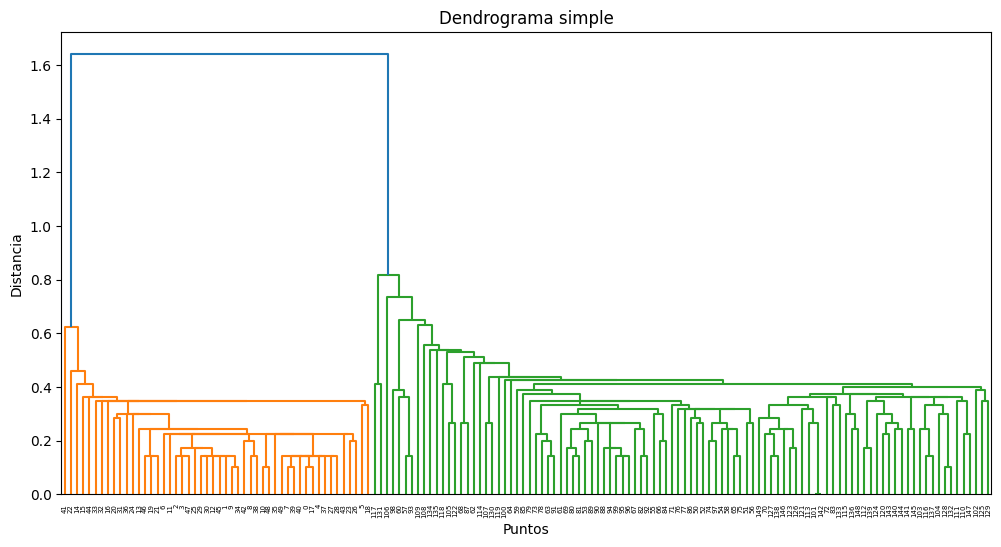

In [ ]:
# dendrograma
Z_s = linkage(X,'single')

plt.figure(figsize = (12,6))
dendrogram(Z_s)
plt.xlabel('Puntos')
plt.ylabel('Distancia')
plt.title('Dendrograma simple')
plt.show()

In [ ]:
iris_hcs = iris.copy()
max_d=1
clusters = fcluster(Z_s, max_d, criterion='distance')
iris_hcs['cluster'] = clusters
iris_hcs['cluster'] = iris_hcs['cluster'].astype(str)

fig = px.scatter(iris_hcs,x= 'sepal_length',y='petal_length', color ='cluster',title='HCS' )
fig.show()

In [ ]:
Z_c = linkage(X,'complete')

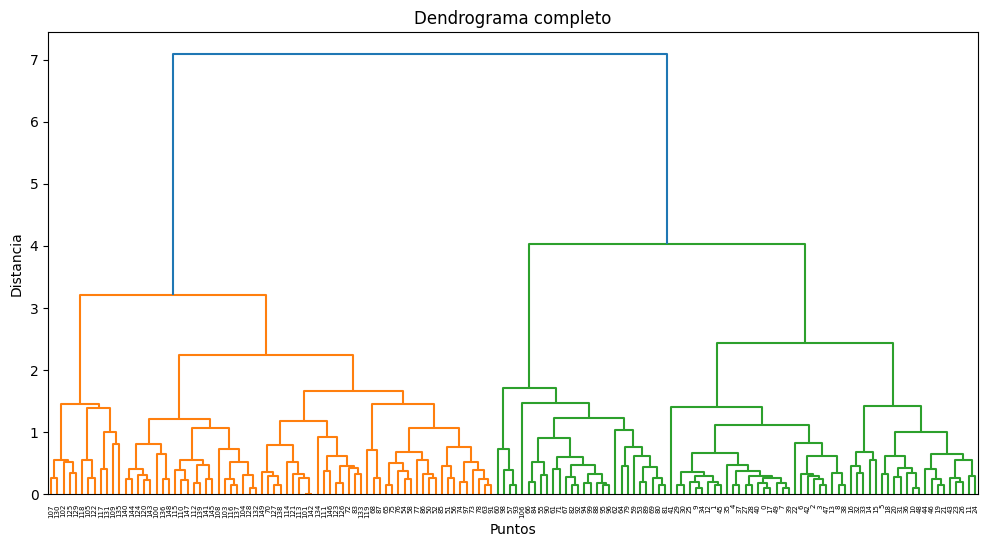

In [ ]:
plt.figure(figsize = (12,6))
dendrogram(Z_c)
plt.xlabel('Puntos')
plt.ylabel('Distancia')
plt.title('Dendrograma completo')
plt.show()

In [ ]:
iris_hcc = iris.copy()
max_d=4
clusters = fcluster(Z_c, max_d, criterion='distance')
iris_hcc['cluster'] = clusters
iris_hcc['cluster'] = iris_hcc['cluster'].astype(str)

fig = px.scatter(iris_hcc,x= 'sepal_length',y='petal_length', color ='cluster',title='HCC' )
fig.show()

In [ ]:
Z_a = linkage(X,'average')

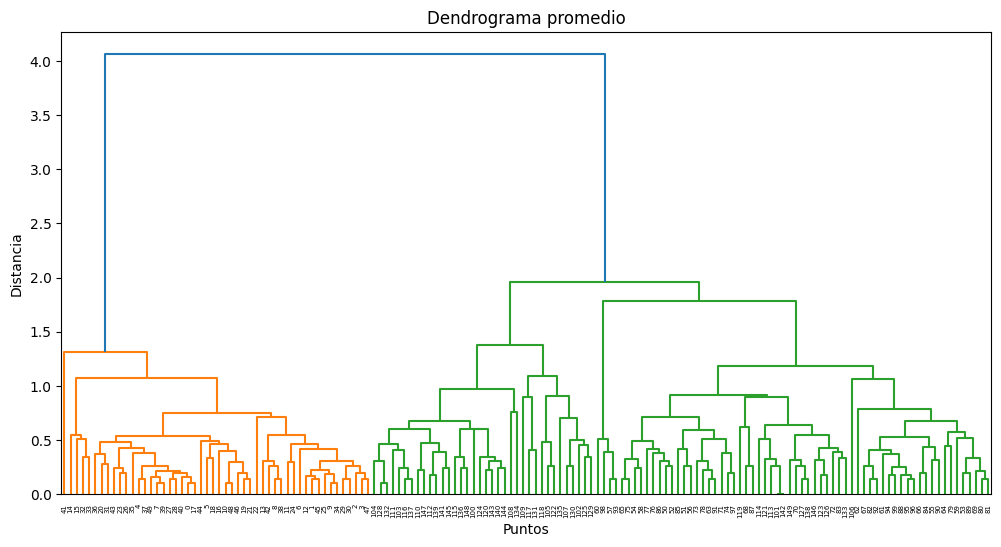

In [ ]:
plt.figure(figsize = (12,6))
dendrogram(Z_a)
plt.xlabel('Puntos')
plt.ylabel('Distancia')
plt.title('Dendrograma promedio')
plt.show()

In [ ]:
iris_hca = iris.copy()
max_d=3
clusters = fcluster(Z_c, max_d, criterion='distance')
iris_hca['cluster'] = clusters
iris_hca['cluster'] = iris_hca['cluster'].astype(str)

fig = px.scatter(iris_hca,x= 'sepal_length',y='petal_length', color ='cluster',title='HCA' )
fig.show()

In [ ]:
#Nuevo modelo

#Nuevo modelo

In [ ]:
dbscan= (DBSCAN(eps=0.5, min_samples=5))
Clusters =dbscan.fit_predict(X)

In [ ]:
iris_dbs = iris.copy()
iris_dbs['cluster'] = Clusters.astype(str)
fig= px.scatter(iris_dbs, x = 'sepal_length', y = 'petal_length', color = 'cluster', title = 'DBSCAN')
fig.show()

In [ ]:
dbscan= (DBSCAN(eps=0.8, min_samples=5))
cluster =dbscan.fit_predict(X)

iris_dbs = iris.copy()
iris_dbs['cluster'] = cluster.astype(str)
fig= px.scatter(iris_dbs, x = 'sepal_length', y = 'petal_length', color = 'cluster', title = 'DBSCAN')
fig.show()

#Reduccion de columnas

In [ ]:
#PCA
pca= PCA(n_components = 2)
X_pca2 = pd.DataFrame(pca.fit_transform(X))
X_pca2 .columns = ['PCA1', 'PCA2']
X_pca2['Species']= iris['species']
X_pca2

,PCA1,PCA2,Species
0,-2.684126,0.319397,setosa
1,-2.714142,-0.177001,setosa
2,-2.888991,-0.144949,setosa
3,-2.745343,-0.318299,setosa
4,-2.728717,0.326755,setosa
...,...,...,...
145,1.944110,0.187532,virginica
146,1.527167,-0.375317,virginica
147,1.764346,0.078859,virginica
148,1.900942,0.116628,virginica


In [ ]:
fig= px.scatter(X_pca2, x = 'PCA1', y = 'PCA2', title = 'PCA',color = 'Species')
fig.show()

In [ ]:
components = pca. components_
components

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [ ]:
variance = pca.explained_variance_
variance

array([4.22824171, 0.24267075])

In [ ]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.92461872, 0.05306648])

In [ ]:
X_pca2 = X_pca2.drop('Species', axis=1)
X_pca2

,PCA1,PCA2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755
...,...,...
145,1.944110,0.187532
146,1.527167,-0.375317
147,1.764346,0.078859
148,1.900942,0.116628


In [ ]:
WCSS = []
for k in range(1, 11):
  kmeanssca = KMeans(n_clusters = k, random_state=30, n_init =10)
  kmeanssca.fit(X_pca2)
  WCSS.append(kmeanssca.inertia_)

WCSS

[666.1659556405613,
 137.15530112818405,
 63.81994202200117,
 42.25903780942155,
 33.51398303646689,
 26.22785786848977,
 22.04090824018908,
 17.92478148943029,
 15.816446343526744,
 13.8508393390677]

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = list(range(1,11)), y = WCSS, mode = 'lines+markers', name= 'WCSS',
                         ))
fig.update_layout(title = "Metodo del codo", xaxis_title = "Numero of Clusters (k)", yaxis_title = "WCSS",
                  xaxis=dict(tickmode = 'linear',tickvals=list(range(1,11))),yaxis=dict(rangemode ='tozero'),template = "plotly_white")
fig.show()

In [ ]:
kmeanssca = KMeans(n_clusters = 2, random_state=42, n_init = 10)
kmeanssca.fit(X)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
X_pca22 = X_pca2.copy()

In [ ]:
X_pca22['Cluster']= kmeans.labels_
X_pca22['Cluster'] = X_pca22.Cluster.astype(str) #a cadena pq lo pasa en entero
fig = px.scatter(X_pca22, x = 'PCA1', y = 'PCA2', color = 'Cluster', title='Kmeans-2')
fig.show()

In [ ]:
silhouette_scorespca=[]

for k in range(2,11):
  kmeanssca = KMeans(n_clusters = k, random_state=42, n_init =10)
  cluster_labels = kmeanssca.fit_predict(X)
  silhouette_scorespca.append(silhouette_score(X, cluster_labels))
silhouette_scorespca

fig= go.Figure()
fig.add_trace(go.Scatter(x = list(range(2,11)), y = silhouette_scorespca, mode = 'lines+markers', name= 'Silhouette Score',
                         ))
fig.update_layout(title = "Silhouette Score for optimal K", xaxis_title = "Numero of Clusters (k)", yaxis_title = "Silhouette Score",
                  xaxis=dict(tickmode = 'linear',tickvals=list(range(2,11))),yaxis = dict(rangemode ='tozero'),template = "plotly_white")
fig.show()

In [ ]:
pca = PCA(n_components = 3)
X_pca3 = pca.fit_transform(X)
X_pca3

array([[-2.68412563,  0.31939725, -0.02791483],
       [-2.71414169, -0.17700123, -0.21046427],
       [-2.88899057, -0.14494943,  0.01790026],
       [-2.74534286, -0.31829898,  0.03155937],
       [-2.72871654,  0.32675451,  0.09007924],
       [-2.28085963,  0.74133045,  0.16867766],
       [-2.82053775, -0.08946138,  0.25789216],
       [-2.62614497,  0.16338496, -0.02187932],
       [-2.88638273, -0.57831175,  0.02075957],
       [-2.6727558 , -0.11377425, -0.19763272],
       [-2.50694709,  0.6450689 , -0.07531801],
       [-2.61275523,  0.01472994,  0.10215026],
       [-2.78610927, -0.235112  , -0.20684443],
       [-3.22380374, -0.51139459,  0.06129967],
       [-2.64475039,  1.17876464, -0.15162752],
       [-2.38603903,  1.33806233,  0.2777769 ],
       [-2.62352788,  0.81067951,  0.13818323],
       [-2.64829671,  0.31184914,  0.02666832],
       [-2.19982032,  0.87283904, -0.12030552],
       [-2.5879864 ,  0.51356031,  0.21366517],
       [-2.31025622,  0.39134594, -0.239

In [ ]:
components = pca.components_
components

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102],
       [-0.58202985,  0.59791083,  0.07623608,  0.54583143]])

In [ ]:
explained_variance = pca.explained_variance_
explained_variance

array([4.22824171, 0.24267075, 0.0782095 ])

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance_ratio

array([0.92461872, 0.05306648, 0.01710261])

In [ ]:
pca_3 = pd.DataFrame(X_pca3)
pca_3.columns = ['PCA1', 'PCA2', 'PCA3']
pca_3['Species'] = iris['species']


In [ ]:
#pca_3 = pca_3.drop('Species', axis=1)
#pca_3
fig = px.scatter_3d(pca_3, x = 'PCA1', y = 'PCA2', z='PCA3', color = 'Species', title='pca3')
fig.show()

In [ ]:
pca_3 = pca_3.drop('Species', axis=1)
pca_3

,PCA1,PCA2,PCA3
0,-2.684126,0.319397,-0.027915
1,-2.714142,-0.177001,-0.210464
2,-2.888991,-0.144949,0.017900
3,-2.745343,-0.318299,0.031559
4,-2.728717,0.326755,0.090079
...,...,...,...
145,1.944110,0.187532,0.177825
146,1.527167,-0.375317,-0.121898
147,1.764346,0.078859,0.130482
148,1.900942,0.116628,0.723252


In [ ]:
WCSS3 = []
for k in range(1, 11):
  kmeanspca = KMeans(n_clusters = k, random_state=30, n_init =10)
  kmeanspca.fit(X_pca3)
  WCSS3.append(kmeanspca.inertia_)

WCSS3

[677.8191711469556,
 148.79893436516963,
 75.31893784137081,
 53.73894438291908,
 43.245715298825225,
 35.894812584171916,
 31.388579190750622,
 26.968005096827245,
 25.072727684044906,
 23.03374490316809]

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = list(range(1,11)), y = WCSS3, mode = 'lines+markers', name= 'WCSS',
                         ))
fig.update_layout(title = "Metodo del codo", xaxis_title = "Numero of Clusters (k)", yaxis_title = "WCSS",
                  xaxis=dict(tickmode = 'linear',tickvals=list(range(1,11))),yaxis=dict(rangemode ='tozero'),template = "plotly_white")
fig.show()

In [ ]:
kmeanspca = KMeans(n_clusters = 2, random_state=42, n_init = 10)
kmeanspca.fit(X_pca3)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [ ]:
centroids = kmeanspca.cluster_centers_
centers = pd.DataFrame(centroids, columns = ['PCA1', 'PCA2','PCA3']).reset_index()
centers = centers.rename(columns = {'index':'Cluster'})
centers


,Cluster,PCA1,PCA2,PCA3
0,0,1.386401,-0.069804,-0.005908
1,1,-2.537375,0.127755,0.010813


In [ ]:
iris_pca3 = pd.DataFrame(X_pca3)
iris_pca3['cluster'] = kmeans.labels_
iris_pca3['cluster'] = iris_pca3.cluster.astype(str)
iris_pca3.columns = ['PCA1', 'PCA2', 'PCA3', 'cluster']
iris_pca3


,PCA1,PCA2,PCA3,cluster
0,-2.684126,0.319397,-0.027915,1
1,-2.714142,-0.177001,-0.210464,1
2,-2.888991,-0.144949,0.017900,1
3,-2.745343,-0.318299,0.031559,1
4,-2.728717,0.326755,0.090079,1
...,...,...,...,...
145,1.944110,0.187532,0.177825,2
146,1.527167,-0.375317,-0.121898,0
147,1.764346,0.078859,0.130482,2
148,1.900942,0.116628,0.723252,2


In [ ]:
fig = go.Figure()
for k in sorted(iris_pca3.cluster.unique()):
  fig.add_trace(go.Scatter3d(
      x=iris_pca3[iris_pca3.cluster ==k].PCA1,
      y=iris_pca3[iris_pca3.cluster ==k].PCA2,
      z=iris_pca3[iris_pca3.cluster ==k].PCA3,
      mode = 'marker',
      name = f'Cluster {k}'
  ))
fig.add_trace(go.Scatter3d(
    x = centers.PCA1,
    y = centers.PCA2,
    z = centers.PCA3,
    mode = 'markers',
    name = 'Centroids',
    marker_color ='Black',
    marker_size =10
))
fig.show()

ValueError: 
    Invalid value of type 'builtins.str' received for the 'mode' property of scatter3d
        Received value: 'marker'

    The 'mode' property is a flaglist and may be specified
    as a string containing:
      - Any combination of ['lines', 'markers', 'text'] joined with '+' characters
        (e.g. 'lines+markers')
        OR exactly one of ['none'] (e.g. 'none')